#Feature Scaling
##Normalization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

df = pd.read_csv(f"{path}/winequality-red.csv")
df.head()


Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [7]:
df = df[['volatile acidity', 'chlorides', 'total sulfur dioxide', 'alcohol']]
df

,volatile acidity,chlorides,total sulfur dioxide,alcohol
0,0.700,0.076,34.0,9.4
1,0.880,0.098,67.0,9.8
2,0.760,0.092,54.0,9.8
3,0.280,0.075,60.0,9.8
4,0.700,0.076,34.0,9.4
...,...,...,...,...
1594,0.600,0.090,44.0,10.5
1595,0.550,0.062,51.0,11.2
1596,0.510,0.076,40.0,11.0
1597,0.645,0.075,44.0,10.2


<Axes: xlabel='alcohol', ylabel='Density'>

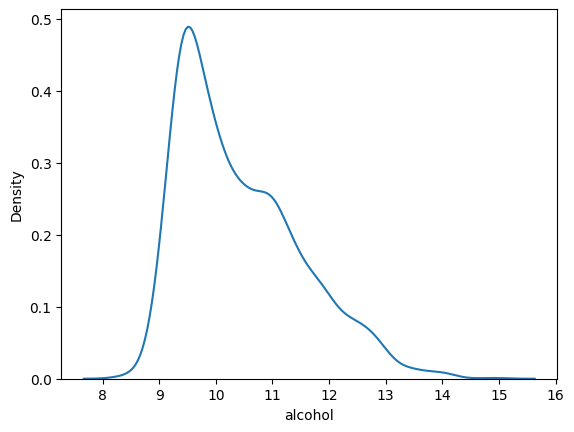

In [8]:
sns.kdeplot(df['alcohol'])

<Axes: xlabel='alcohol', ylabel='volatile acidity'>

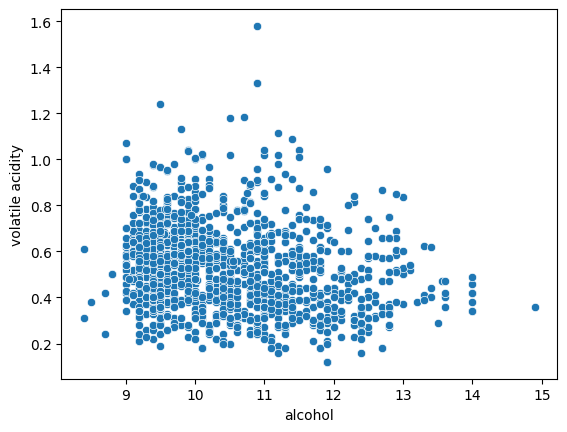

In [9]:
sns.scatterplot(x=df['alcohol'], y=df['volatile acidity'])

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('volatile acidity',axis=1), df['volatile acidity'],test_size=0.2,random_state=0)


In [14]:
X_train.shape,X_test.shape

((1279, 3), (320, 3))

In [16]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

X_train_scaled.describe()


,chlorides,total sulfur dioxide,alcohol
count,1279.000000,1279.000000,1279.000000
mean,0.125249,0.145280,0.309845
std,0.079801,0.118672,0.163278
min,0.000000,0.000000,0.000000
25%,0.096828,0.056537,0.169231
50%,0.111853,0.113074,0.276923
75%,0.130217,0.201413,0.412821
max,1.000000,1.000000,1.000000


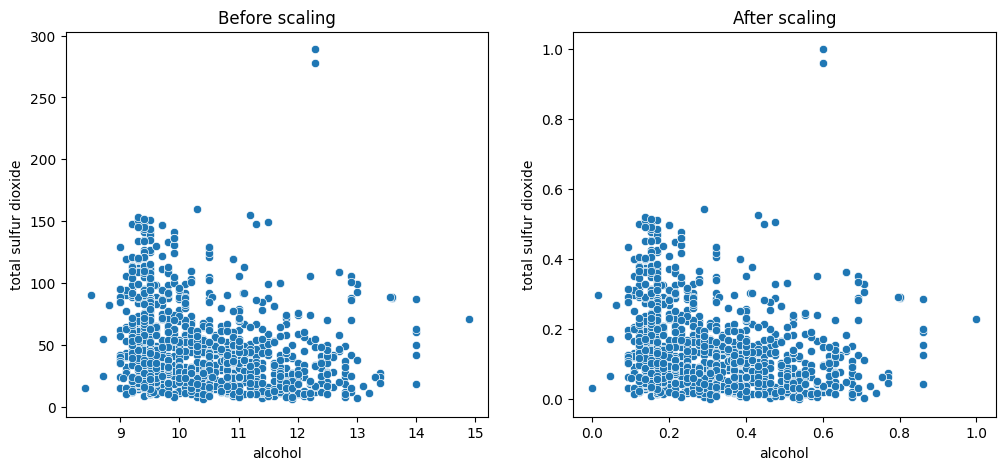

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Before scaling
sns.scatterplot(
    x='alcohol',
    y='total sulfur dioxide',
    data=X_train,
    ax=ax1
)
ax1.set_title('Before scaling')

# After scaling
sns.scatterplot(
    x='alcohol',
    y='total sulfur dioxide',
    data=X_train_scaled,
    ax=ax2
)
ax2.set_title('After scaling')

plt.show()
